# 03 - Modelo ANN 1: Regresión de la calidad del vino

**Curso:** BD-151 Inteligencia Artificial Aplicada · **Proyecto D:** Sistema de Predicción de Calidad de Vino

**Objetivo:** entrenar una red neuronal artificial (ANN) que prediga la puntuación de calidad (`quality`, escala 0-10) a partir de las 11 propiedades fisicoquímicas y el tipo de vino.

**Qué se hace en este notebook**

1. Cargar los datos ya preprocesados (notebook 02).
2. Diseñar la arquitectura de la red.
3. Entrenar **3 configuraciones** (con y sin Dropout) usando `EarlyStopping`.
4. Evaluar con **MAE** y **RMSE** (y R² como apoyo) sobre el conjunto de prueba.
5. Graficar el entrenamiento y los errores.
6. Guardar los modelos `.keras` y las métricas para el notebook 05 (comparación).

## 1. Importación de librerías y configuración

In [2]:
import sys, json, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Busca la raíz del proyecto (la carpeta que contiene src/config.py),
# sin importar desde dónde se ejecute el notebook (notebooks/, raíz, PyCharm, Jupyter...)
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists()), None)
if ROOT is None:
    raise FileNotFoundError("No se encontró la raíz del proyecto (src/config.py). Abre el notebook dentro del repositorio.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.config import ProjectConfig

# Reproducibilidad
SEED = ProjectConfig.RANDOM_STATE
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

sns.set_theme(style="whitegrid")
ProjectConfig.create_directories()

METRICS_DIR = ProjectConfig.REPORTS_DIR / "metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Semilla:", SEED)
print("Raíz del proyecto:", ROOT)

TensorFlow: 2.22.0-rc0
Semilla: 42
Raíz del proyecto: C:\Users\Eladrel\Desktop\Proyecto-D-Sistema-de-Prediccion-de-Calidad-de-Vino-main


## 2. Carga de datos preprocesados

Los datos provienen del notebook 02 (limpieza, variable dummy `wine_type_white`, división 80/20 estratificada y normalización con `StandardScaler` ajustado **solo con entrenamiento**). Para regresión el objetivo es `quality`.

In [3]:
X_train = pd.read_csv(ProjectConfig.X_TRAIN_FILE)
X_test  = pd.read_csv(ProjectConfig.X_TEST_FILE)
y_train = pd.read_csv(ProjectConfig.Y_TRAIN_REGRESSION_FILE)["quality"]
y_test  = pd.read_csv(ProjectConfig.Y_TEST_REGRESSION_FILE)["quality"]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)
print("\nColumnas de entrada:", list(X_train.columns))
print("Valores nulos en X_train:", int(X_train.isnull().sum().sum()))
X_train.head()

X_train: (4256, 12) | X_test: (1064, 12)
y_train: (4256,) | y_test: (1064,)

Columnas de entrada: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'ph', 'sulphates', 'alcohol', 'wine_type_white']
Valores nulos en X_train: 0


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,wine_type_white
0,-0.994120,-0.505515,-0.542621,-0.592638,-0.288436,-0.164518,0.319999,-0.743530,2.569540,1.328492,0.635962,0.584586
1,0.061465,0.451759,0.406770,0.382845,-0.314551,-0.053183,0.144239,-0.689620,-0.214790,-1.092401,1.732778,0.584586
2,-0.466327,0.571418,-1.559825,-0.636978,0.155518,-1.166538,-1.683656,-0.035963,1.240655,1.059504,0.635962,-1.710614
3,-0.692524,-1.283300,0.678025,-0.880849,-0.366781,1.839521,0.566061,-1.309584,-0.594471,1.261245,0.551592,0.584586
4,-1.220317,-0.924322,-0.406993,-0.814338,-0.706275,-0.999534,-0.664253,-1.363493,0.164891,-1.092401,0.298480,0.584586


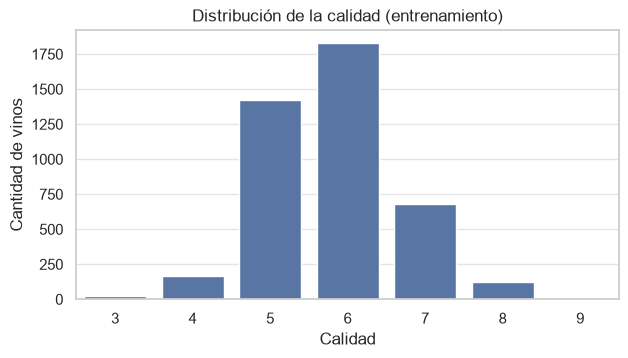

In [4]:
# Distribución de la variable objetivo (calidad)
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.countplot(x=y_train, ax=ax, color="#4C72B0")
ax.set_title("Distribución de la calidad (entrenamiento)")
ax.set_xlabel("Calidad"); ax.set_ylabel("Cantidad de vinos")
plt.show()

### 2.1 Conjunto de validación

`EarlyStopping` necesita monitorear una métrica de validación. Para **no usar el conjunto de prueba durante el entrenamiento** (evitaría una evaluación final honesta), se separa un 15 % del conjunto de entrenamiento como validación. El conjunto de prueba solo se usa en la evaluación final.

In [5]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED
)
print("Entrenamiento:", X_tr.shape[0], "| Validación:", X_val.shape[0], "| Prueba:", X_test.shape[0])

Entrenamiento: 3617 | Validación: 639 | Prueba: 1064


## 3. Diseño de la arquitectura

Red densa (*feed-forward*) para regresión:

- **Capas ocultas:** `Dense` con activación **ReLU**.
- **Dropout (opcional):** apaga aleatoriamente un porcentaje de neuronas en cada paso de entrenamiento para reducir el sobreajuste.
- **Capa de salida:** 1 neurona **sin activación** (lineal), porque se predice un valor numérico continuo.
- **Pérdida:** `mse` (error cuadrático medio). **Optimizador:** Adam. **Métrica monitoreada:** `mae`.

Se define una función para construir cada configuración y poder compararlas bajo las mismas condiciones.

In [6]:
def build_regression_model(hidden_units, dropout=0.0, learning_rate=0.001, name="modelo"):
    """Construye una ANN de regresión.

    hidden_units : lista con el número de neuronas de cada capa oculta
    dropout      : tasa de Dropout aplicada después de cada capa oculta (0 = sin Dropout)
    """
    model = keras.Sequential(name=name)
    model.add(layers.Input(shape=(X_train.shape[1],)))
    for units in hidden_units:
        model.add(layers.Dense(units, activation="relu"))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))  # salida lineal: calidad (0-10)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"],
    )
    return model


# Configuraciones a probar
CONFIGS = {
    "A_sin_dropout":   {"hidden_units": [64, 32],     "dropout": 0.0},
    "B_dropout_0.2":   {"hidden_units": [64, 32],     "dropout": 0.2},
    "C_profunda_drop": {"hidden_units": [128, 64, 32], "dropout": 0.2},
}

build_regression_model(**CONFIGS["B_dropout_0.2"], name="ejemplo").summary()

Model: "ejemplo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento con EarlyStopping

`EarlyStopping` detiene el entrenamiento cuando la pérdida de validación (`val_loss`) deja de mejorar durante `patience` épocas y **restaura los pesos de la mejor época** (`restore_best_weights=True`). Así no hace falta adivinar el número exacto de épocas.

In [14]:
EPOCHS = 300
BATCH_SIZE = 32
PATIENCE = 20

models, histories = {}, {}

for cfg_name, cfg in CONFIGS.items():
    keras.utils.set_random_seed(SEED)           # misma semilla para comparar justo
    model = build_regression_model(**cfg, name=cfg_name.replace(".", "_"))

    early_stop = EarlyStopping(
        monitor="val_loss", patience=PATIENCE,
        restore_best_weights=True, verbose=0,
    )
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=[early_stop], verbose=0,
    )
    models[cfg_name], histories[cfg_name] = model, hist
    best_epoch = int(np.argmin(hist.history["val_loss"])) + 1
    print(f"{cfg_name:16s} | épocas ejecutadas: {len(hist.history['loss']):3d} "
          f"| mejor época: {best_epoch:3d} | mejor val_loss: {min(hist.history['val_loss']):.4f}")

A_sin_dropout    | épocas ejecutadas:  40 | mejor época:  20 | mejor val_loss: 0.5442
B_dropout_0.2    | épocas ejecutadas: 170 | mejor época: 150 | mejor val_loss: 0.5054
C_profunda_drop  | épocas ejecutadas:  71 | mejor época:  51 | mejor val_loss: 0.5151


### 4.1 Curvas de entrenamiento

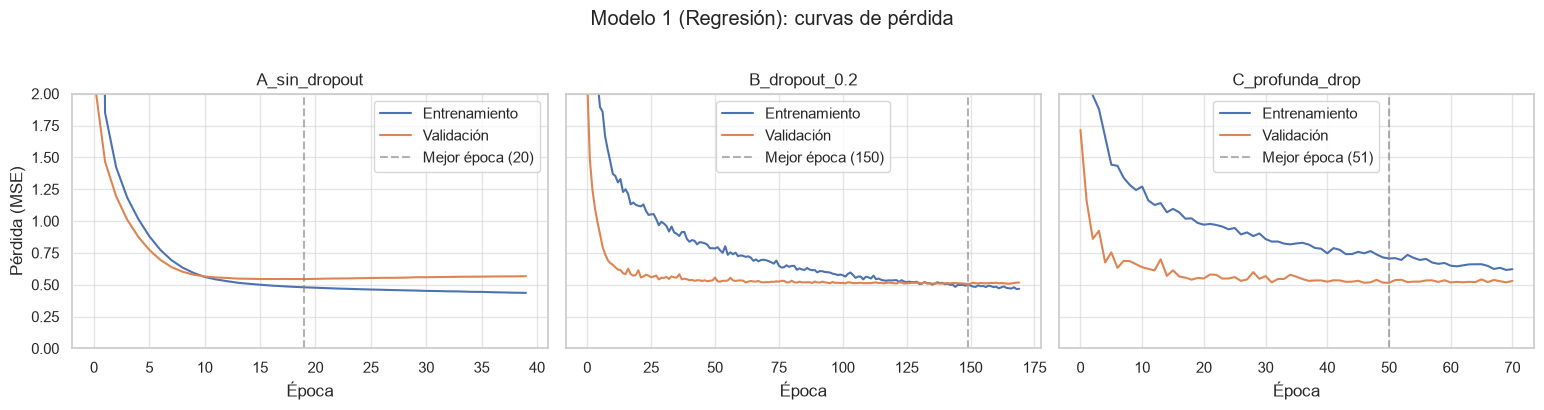

In [8]:
fig, axes = plt.subplots(1, len(CONFIGS), figsize=(5.2 * len(CONFIGS), 4), sharey=True)
for ax, (cfg_name, hist) in zip(axes, histories.items()):
    h = pd.DataFrame(hist.history)
    ax.plot(h["loss"], label="Entrenamiento")
    ax.plot(h["val_loss"], label="Validación")
    best = int(h["val_loss"].idxmin())
    ax.axvline(best, color="gray", linestyle="--", alpha=0.6, label=f"Mejor época ({best + 1})")
    ax.set_title(cfg_name); ax.set_xlabel("Época")
    ax.set_ylim(0, 2)   # zoom: la 1ª época (pérdida ~12) aplasta la escala
    ax.legend()
axes[0].set_ylabel("Pérdida (MSE)")
plt.suptitle("Modelo 1 (Regresión): curvas de pérdida", y=1.02)
plt.tight_layout()
plt.savefig(ProjectConfig.FIGURES_DIR / "modelo1_curvas_perdida.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Evaluación en el conjunto de prueba

Métricas:

- **MAE** (error absoluto medio): en promedio, cuántos puntos de calidad se equivoca el modelo.
- **RMSE** (raíz del error cuadrático medio): como el MAE pero penaliza más los errores grandes.
- **R²**: proporción de la variabilidad explicada (1 = perfecto, 0 = igual que predecir el promedio).

Como referencia se incluye un **modelo base** que siempre predice el promedio de calidad del entrenamiento: la red debe superarlo para tener sentido.

In [9]:
def evaluate_regression(y_true, y_pred):
    y_pred = np.asarray(y_pred).ravel()
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2":   r2_score(y_true, y_pred),
    }

rows = []
# Línea base: predecir siempre la media
base_pred = np.full(len(y_test), y_train.mean())
rows.append({"Configuración": "Base (promedio)", **evaluate_regression(y_test, base_pred),
             "Épocas": 0, "Parámetros": 0})

predictions = {}
for cfg_name, model in models.items():
    pred = model.predict(X_test, verbose=0).ravel()
    predictions[cfg_name] = pred
    val_mae = mean_absolute_error(y_val, model.predict(X_val, verbose=0).ravel())
    rows.append({
        "Configuración": cfg_name,
        **evaluate_regression(y_test, pred),
        "Épocas": len(histories[cfg_name].history["loss"]),
        "Parámetros": model.count_params(),
        "MAE_val": val_mae,
    })

results = pd.DataFrame(rows).set_index("Configuración")
results.round(4)

,MAE,RMSE,R2,Épocas,Parámetros,MAE_val
Configuración,,,,,,
Base (promedio),0.6708,0.8498,-0.0012,0,0,NaN
A_sin_dropout,0.5427,0.6999,0.3207,40,2945,0.5665
B_dropout_0.2,0.5193,0.6610,0.3941,170,2945,0.5443
C_profunda_drop,0.5221,0.6662,0.3845,71,12033,0.5514


### 5.1 Valor real vs. valor predicho y distribución del error

La calidad real es un número entero y el modelo predice un valor continuo, por eso los puntos se agrupan en columnas verticales. Una predicción perfecta caería sobre la línea roja.

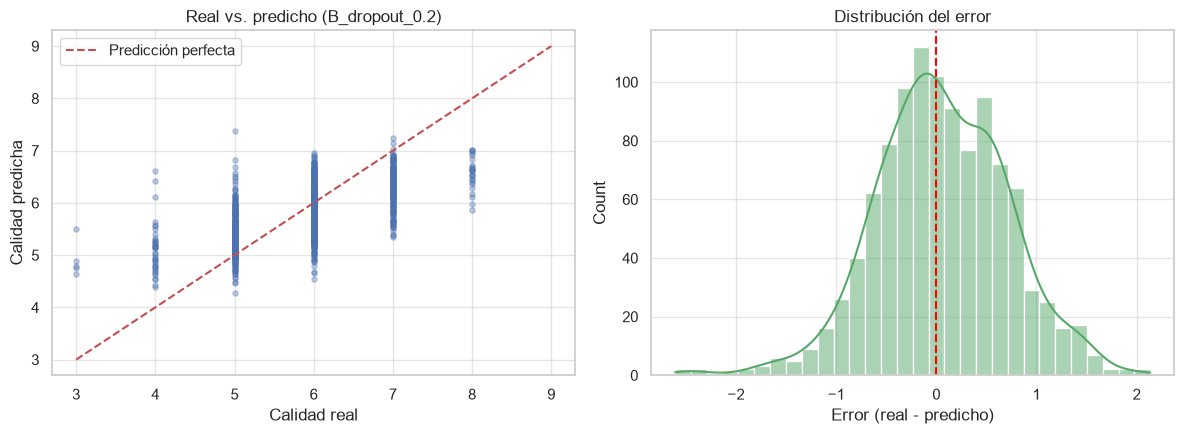

Media del error: +0.054 | Desv. estándar: 0.659
Predicciones dentro de ±0.5 puntos: 55.1%
Predicciones dentro de ±1.0 punto : 88.3%


In [10]:
best_name = results.drop(index="Base (promedio)")["MAE_val"].idxmin()   # elegido con VALIDACIÓN, no con prueba
best_pred = predictions[best_name]
errors = y_test.values - best_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_test, best_pred, alpha=0.35, s=14)
axes[0].plot([3, 9], [3, 9], "r--", label="Predicción perfecta")
axes[0].set_xlabel("Calidad real"); axes[0].set_ylabel("Calidad predicha")
axes[0].set_title(f"Real vs. predicho ({best_name})"); axes[0].legend()

sns.histplot(errors, bins=30, kde=True, ax=axes[1], color="#55A868")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Error (real - predicho)"); axes[1].set_title("Distribución del error")

plt.tight_layout()
plt.savefig(ProjectConfig.FIGURES_DIR / "modelo1_real_vs_predicho.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Media del error: {errors.mean():+.3f} | Desv. estándar: {errors.std():.3f}")
print(f"Predicciones dentro de ±0.5 puntos: {np.mean(np.abs(errors) <= 0.5):.1%}")
print(f"Predicciones dentro de ±1.0 punto : {np.mean(np.abs(errors) <= 1.0):.1%}")

In [11]:
# Error promedio según la calidad real: ¿dónde falla más el modelo?
err_by_q = (pd.DataFrame({"calidad_real": y_test.values, "error_abs": np.abs(errors)})
            .groupby("calidad_real")["error_abs"].agg(["mean", "count"]).round(3))
err_by_q.columns = ["MAE", "n_vinos"]
err_by_q

,MAE,n_vinos
calidad_real,,
3,1.911,5
4,1.118,38
5,0.445,328
6,0.388,491
7,0.724,177
8,1.443,25


## 6. Guardado de modelos y métricas

- Cada configuración se guarda como `models/model1_<config>.keras` (el notebook 05 las compara).
- La mejor configuración según la **validación** se guarda además como `models/model1.keras`, que es el archivo que usará la API.
- Las métricas y el historial de cada configuración se guardan en `reports/metrics/` para el notebook 05.

In [12]:
for cfg_name, model in models.items():
    model.save(ProjectConfig.MODELS_DIR / f"model1_{cfg_name}.keras")
    pd.DataFrame(histories[cfg_name].history).to_csv(
        METRICS_DIR / f"model1_history_{cfg_name}.csv", index_label="epoch")

# Mejor configuración -> model1.keras (archivo que consumirá la API)
models[best_name].save(ProjectConfig.MODELS_DIR / "model1.keras")

results.to_csv(METRICS_DIR / "model1_results.csv")
with open(METRICS_DIR / "model1_best_config.json", "w", encoding="utf-8") as f:
    json.dump({"best_config": best_name, **CONFIGS[best_name]}, f, indent=2)

print("Mejor configuración (por validación):", best_name)
print("Guardado en:", ProjectConfig.MODELS_DIR / "model1.keras")

Mejor configuración (por validación): B_dropout_0.2
Guardado en: C:\Users\Eladrel\Desktop\Proyecto-D-Sistema-de-Prediccion-de-Calidad-de-Vino-main\models\model1.keras


In [13]:
# Verificación: el modelo guardado debe dar exactamente las mismas predicciones
reloaded = keras.models.load_model(ProjectConfig.MODELS_DIR / "model1.keras")
same = np.allclose(reloaded.predict(X_test, verbose=0).ravel(), best_pred, atol=1e-5)
print("Modelo recargado produce las mismas predicciones:", same)

Modelo recargado produce las mismas predicciones: True


## 7. Conclusiones

*(Completar con los resultados finales después de ejecutar el notebook; ver la tabla de la sección 5.)*

- Configuración elegida y por qué.
- Cuánto mejora el MAE/RMSE respecto al modelo base (predecir el promedio).
- Efecto de Dropout y de la profundidad de la red.
- Limitaciones: la calidad está concentrada en 5-6, por lo que el modelo tiende a "encoger" las predicciones hacia el centro y falla más en las calidades extremas (3, 4, 8, 9).